# 🎯 YOLOv8 + Transfer Learning — Notebook completo para Google Colab

Pipeline de ponta a ponta:
1. Setup (GPU + Ultralytics)
2. **Carregar dataset** — 3 opções: Drive, Upload ZIP, ou Dataset Público
3. Diagnóstico da estrutura do dataset
4. Configurar `data.yaml` com **detecção automática** dos caminhos
5. **Transfer learning** sobre YOLOv8n (COCO 80 classes)
6. Validar métricas
7. Detectar em imagens (customizado / COCO / **combinado**)
8. Salvar pesos no Drive

## ⚙️ Antes de começar
`Ambiente de execução → Alterar tipo de ambiente → GPU (T4)`

---
## 1. Setup — verificar GPU e instalar Ultralytics

In [29]:
!nvidia-smi

Tue Apr 14 18:08:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [30]:
!pip install -q ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [31]:
# Criar a pasta de trabalho e entrar nela
from pathlib import Path
import os

WORK = Path('/content/yolo_project')
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print(f'Pasta de trabalho: {WORK}')

Pasta de trabalho: /content/yolo_project


---
## 2. Carregar o dataset

**Escolha UMA das 3 opções abaixo** (execute apenas a célula da opção escolhida):

- **Opção A — Google Drive** (recomendado se você tem um dataset seu)
- **Opção B — Upload de ZIP** (dataset pequeno do seu PC)
- **Opção C — Dataset Público** (pronto para rodar, sem precisar ter nada seu)

### 🅰️ Opção A — Carregar do Google Drive

**Estruture seu Drive assim antes:**
```
MyDrive/
└── yolo_project/
    └── dataset/
        ├── images/
        │   ├── train/
        │   └── val/
        └── labels/
            ├── train/
            └── val/
```

_Não precisa ser exatamente essa estrutura — a seção 4 detecta automaticamente._

### 🅱️ Opção B — Upload de ZIP do seu computador

Antes: compacte sua pasta `dataset/` num `dataset.zip` no seu PC.

In [33]:
# ===== OPÇÃO B: Upload de ZIP =====
from google.colab import files
import zipfile

print('Selecione seu dataset.zip...')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name) as z:
    z.extractall('/content/yolo_project/')

print(f'\n✅ {zip_name} extraído')
!ls /content/yolo_project/

Selecione seu dataset.zip...


Saving dataset.zip to dataset (2).zip

✅ dataset (2).zip extraído
 dataset	   'dataset (2).zip'   runs    val
'dataset (1).zip'   dataset.zip        train   yolov8n.pt


### 🅲 Opção C — Dataset público (Hard Hat Workers — EPIs)

**Classes:** `head`, `helmet`, `person`.
Use esta opção para testar o pipeline sem precisar de dados próprios.

---
## 3. Diagnóstico — ver a estrutura real do dataset

Independente da opção escolhida, esta célula mostra exatamente como o dataset está organizado. É útil para debugar problemas de caminho.

In [34]:
from pathlib import Path

data_dir = Path('/content/yolo_project/dataset')

print('=== Estrutura do dataset (até 3 níveis) ===\n')
for p in sorted(data_dir.rglob('*')):
    rel = p.relative_to(data_dir)
    depth = len(rel.parts)
    if depth > 3:
        continue
    indent = '  ' * (depth - 1)
    if p.is_dir():
        n_files = sum(1 for _ in p.iterdir())
        print(f'{indent}📁 {p.name}/ ({n_files} itens)')
    elif depth <= 2 and p.suffix in ('.yaml', '.yml', '.txt'):
        print(f'{indent}📄 {p.name}')

# Mostra o data.yaml original, se existir
yamls = list(data_dir.rglob('data.yaml')) + list(data_dir.rglob('*.yaml'))
if yamls:
    print(f'\n=== data.yaml original em {yamls[0]} ===')
    print(yamls[0].read_text())
else:
    print('\n⚠️  Nenhum data.yaml encontrado no dataset')

=== Estrutura do dataset (até 3 níveis) ===

📁 .ipynb_checkpoints/ (0 itens)
📄 data.yaml
📁 images/ (3 itens)
  📁 .ipynb_checkpoints/ (0 itens)
  📁 train/ (1 itens)
  📁 val/ (1 itens)
📄 requirements.txt

=== data.yaml original em /content/yolo_project/dataset/data.yaml ===
# data.yaml — configuração do dataset customizado para transfer learning
# YOLOv8 (Ultralytics) usa este arquivo para saber onde estão imagens/labels
# e quais são as classes.

# Caminhos relativos ao diretório do projeto
path: ./dataset          # raiz do dataset
train: images/train      # imagens de treino
val: images/val          # imagens de validação

# Classes customizadas (pelo menos 2, conforme requisito)
# Troque para o seu domínio antes de rotular/treinar
names:
  0: capacete_seguranca
  1: colete_refletivo



---
## 4. Configurar `data.yaml` — detecção automática de caminhos

Esta célula encontra as pastas de train/val **qualquer que seja o layout**:
- `images/train` + `images/val`
- `train/images` + `valid/images` (padrão Roboflow)
- `train` + `valid`
- etc.

**⚠️ Se for Opção A ou B sem `data.yaml` pronto**, edite a lista `names` no final da célula para suas classes.

In [35]:
import yaml
from pathlib import Path

data_dir = Path('/content/yolo_project/dataset')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def count_images(folder: Path) -> int:
    if not folder.is_dir():
        return 0
    return sum(1 for f in folder.rglob('*') if f.suffix.lower() in IMG_EXTS and f.is_file())

def find_split_dir(keywords_priority):
    """
    Procura uma pasta com imagens cujo caminho contenha um dos keywords.
    keywords_priority: lista de keywords em ordem de preferência.
    Retorna a pasta com mais imagens que bate no keyword mais prioritário.
    """
    for kw in keywords_priority:
        candidates = []
        for p in data_dir.rglob('*'):
            if not p.is_dir():
                continue
            path_str = str(p).lower()
            # Requer que a pasta contenha o keyword E tenha imagens diretamente
            if kw in path_str:
                n = sum(1 for f in p.iterdir()
                        if f.is_file() and f.suffix.lower() in IMG_EXTS)
                if n > 0:
                    candidates.append((p, n))
        if candidates:
            # Retorna a pasta com mais imagens
            candidates.sort(key=lambda x: -x[1])
            return candidates[0][0]
    return None

# Prioriza padrões mais específicos
train_dir = find_split_dir([
    'train/images', 'images/train', '/train', 'train',
])
val_dir = find_split_dir([
    'valid/images', 'val/images', 'images/valid', 'images/val',
    '/valid', '/val', 'valid', 'val',
])

print(f'📁 Train images: {train_dir}')
print(f'📁 Val images:   {val_dir}')

if not train_dir or not val_dir:
    raise RuntimeError(
        '❌ Não encontrei pastas de train/val com imagens.\n'
        'Rode a célula de diagnóstico (seção 3) e veja a estrutura real.\n'
        'Se necessário, defina manualmente:\n'
        '    train_dir = Path("/content/yolo_project/dataset/train")\n'
        '    val_dir   = Path("/content/yolo_project/dataset/val")'
    )

# ---- Classes: tenta reaproveitar do data.yaml original ----
existing_yamls = list(data_dir.rglob('data.yaml')) + list(data_dir.rglob('*.yaml'))
names = None
for y in existing_yamls:
    try:
        orig = yaml.safe_load(y.read_text())
        if orig and 'names' in orig:
            names = orig['names']
            print(f'\n✅ Classes reaproveitadas de {y.name}: {names}')
            break
    except Exception:
        continue

if names is None:
    # ⚠️ EDITE AQUI se estiver usando seu próprio dataset sem data.yaml
    names = {
        0: 'classe_1',
        1: 'classe_2',
    }
    print(f'\n⚠️  Nenhum data.yaml encontrado. Classes padrão: {names}')
    print('    EDITE o dict `names` acima se necessário!')

# ---- Monta o data.yaml final ----
cfg = {
    'path': str(data_dir),
    'train': str(train_dir.relative_to(data_dir)),
    'val':   str(val_dir.relative_to(data_dir)),
    'names': names,
}

DATA_YAML = Path('/content/yolo_project/dataset/data.yaml')
DATA_YAML.write_text(yaml.safe_dump(cfg, sort_keys=False))

print('\n=== data.yaml final ===')
print(DATA_YAML.read_text())

# ---- Sanity check ----
print('=== Sanity check ===')
print(f'Train ({train_dir}): {count_images(train_dir)} imagens')
print(f'Val   ({val_dir}):   {count_images(val_dir)} imagens')

# Verificar também se existem labels correspondentes
def find_labels(img_dir: Path) -> Path:
    """Encontra a pasta de labels correspondente à de imagens."""
    # tenta substituir 'images' por 'labels' no caminho
    candidates = [
        Path(str(img_dir).replace('/images', '/labels').replace('images/', 'labels/')),
        img_dir.parent / 'labels',
    ]
    for c in candidates:
        if c.is_dir() and list(c.glob('*.txt')):
            return c
    return None

train_labels = find_labels(train_dir)
val_labels = find_labels(val_dir)
print(f'Labels train: {train_labels} ({len(list(train_labels.glob("*.txt"))) if train_labels else 0} arquivos)')
print(f'Labels val:   {val_labels} ({len(list(val_labels.glob("*.txt"))) if val_labels else 0} arquivos)')

📁 Train images: /content/yolo_project/dataset/images/train
📁 Val images:   /content/yolo_project/dataset/images/val

✅ Classes reaproveitadas de data.yaml: {0: 'capacete_seguranca', 1: 'colete_refletivo'}

=== data.yaml final ===
path: /content/yolo_project/dataset
train: images/train
val: images/val
names:
  0: capacete_seguranca
  1: colete_refletivo

=== Sanity check ===
Train (/content/yolo_project/dataset/images/train): 1 imagens
Val   (/content/yolo_project/dataset/images/val):   1 imagens
Labels train: None (0 arquivos)
Labels val:   None (0 arquivos)


---
## 5. Transfer Learning 🚀

**Como funciona:**
- `YOLO('yolov8n.pt')` carrega pesos pré-treinados no **COCO (80 classes)**
- `.train()` com novo `data.yaml` substitui a cabeça de detecção para o novo número de classes, mantendo o backbone já treinado
- `freeze=10` congela as 10 primeiras camadas — fine-tuning só em neck + head (rápido e eficaz para datasets pequenos)

Com GPU T4: ~10–20 min para 25 épocas.

In [37]:
from ultralytics import YOLO

# 1) Modelo pré-treinado no COCO
model = YOLO('yolov8n.pt')

# 2) Fine-tuning nas novas classes
results = model.train(
    data='/content/yolo_project/dataset/data.yaml',
    epochs=25,                # reduza para 5 se só quer testar o pipeline
    imgsz=640,
    batch=16,
    freeze=10,                # congela backbone -> transfer learning
    patience=10,              # early stopping
    project='/content/yolo_project/runs',
    name='train_custom',
    exist_ok=True,            # sobrescreve execuções anteriores
    pretrained=True,
    optimizer='auto',
    lr0=0.01,
    seed=42,
    verbose=True,
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/25     0.135G          0      7.537          0          0        640: 100% ━━━━━━━━━━━━ 1/1 5.2it/s 0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 18.0it/s 0.1s
                   all          1          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/25     0.145G          0      7.544          0          0        640: 100% ━━━━━━━━━━━━ 1/1 10.3it/s 0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 21.2it/s 0.0s
                   all          1          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      25/25      0.15G          0      7.109          0          0        640: 100% ━━━━━━━━━━━━ 1/1 19.1it/s 0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 52.2it/s 0.0s
                   all          1          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



25 epochs completed in 0.003 hours.
Optimizer stripped from /content/yolo_project/runs/train_custom/weights/last.pt, 6.2MB
Optimizer stripped from /content/yolo_project/runs/train_custom/weights/best.pt, 6.2MB

Validating /content/yolo_project/runs/train_custom/weights/best.pt...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 54.1it/s 0.0s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all          1          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.3ms preprocess, 11.4ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/yolo_project/runs/train_custom


---
## 6. Validar métricas e ver gráficos

In [39]:
metrics = model.val()
print(f'\nmAP50    : {metrics.box.map50:.4f}')
print(f'mAP50-95 : {metrics.box.map:.4f}')

from pathlib import Path
BEST = Path('/content/yolo_project/runs/train_custom/weights/best.pt')
print(f'\n✅ Melhor modelo: {BEST} ({BEST.stat().st_size/1e6:.1f} MB)')

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1691.4±0.0 MB/s, size: 76.4 KB)
val: Scanning /content/yolo_project/dataset/labels/val... 0 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 1.6Kit/s 0.0s
WARNING ⚠️ val: No labels found in /content/yolo_project/dataset/labels/val.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
WARNING ⚠️ val: Cache directory /content/yolo_project/dataset/labels is not writable, cache not saved.
WARNING ⚠️ Labels are missing or empty in /content/yolo_project/dataset/labels/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 32.1it/s 0.0s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all          1          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.8ms preprocess, 13.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/yolo_project/runs/detect/val2

mAP50    : 0.0000
mAP50-95 : 0.0000

✅ Melhor modelo: /content/yolo_project/runs/train_custom/weights/best.pt (6.2 MB)



>>> results.png


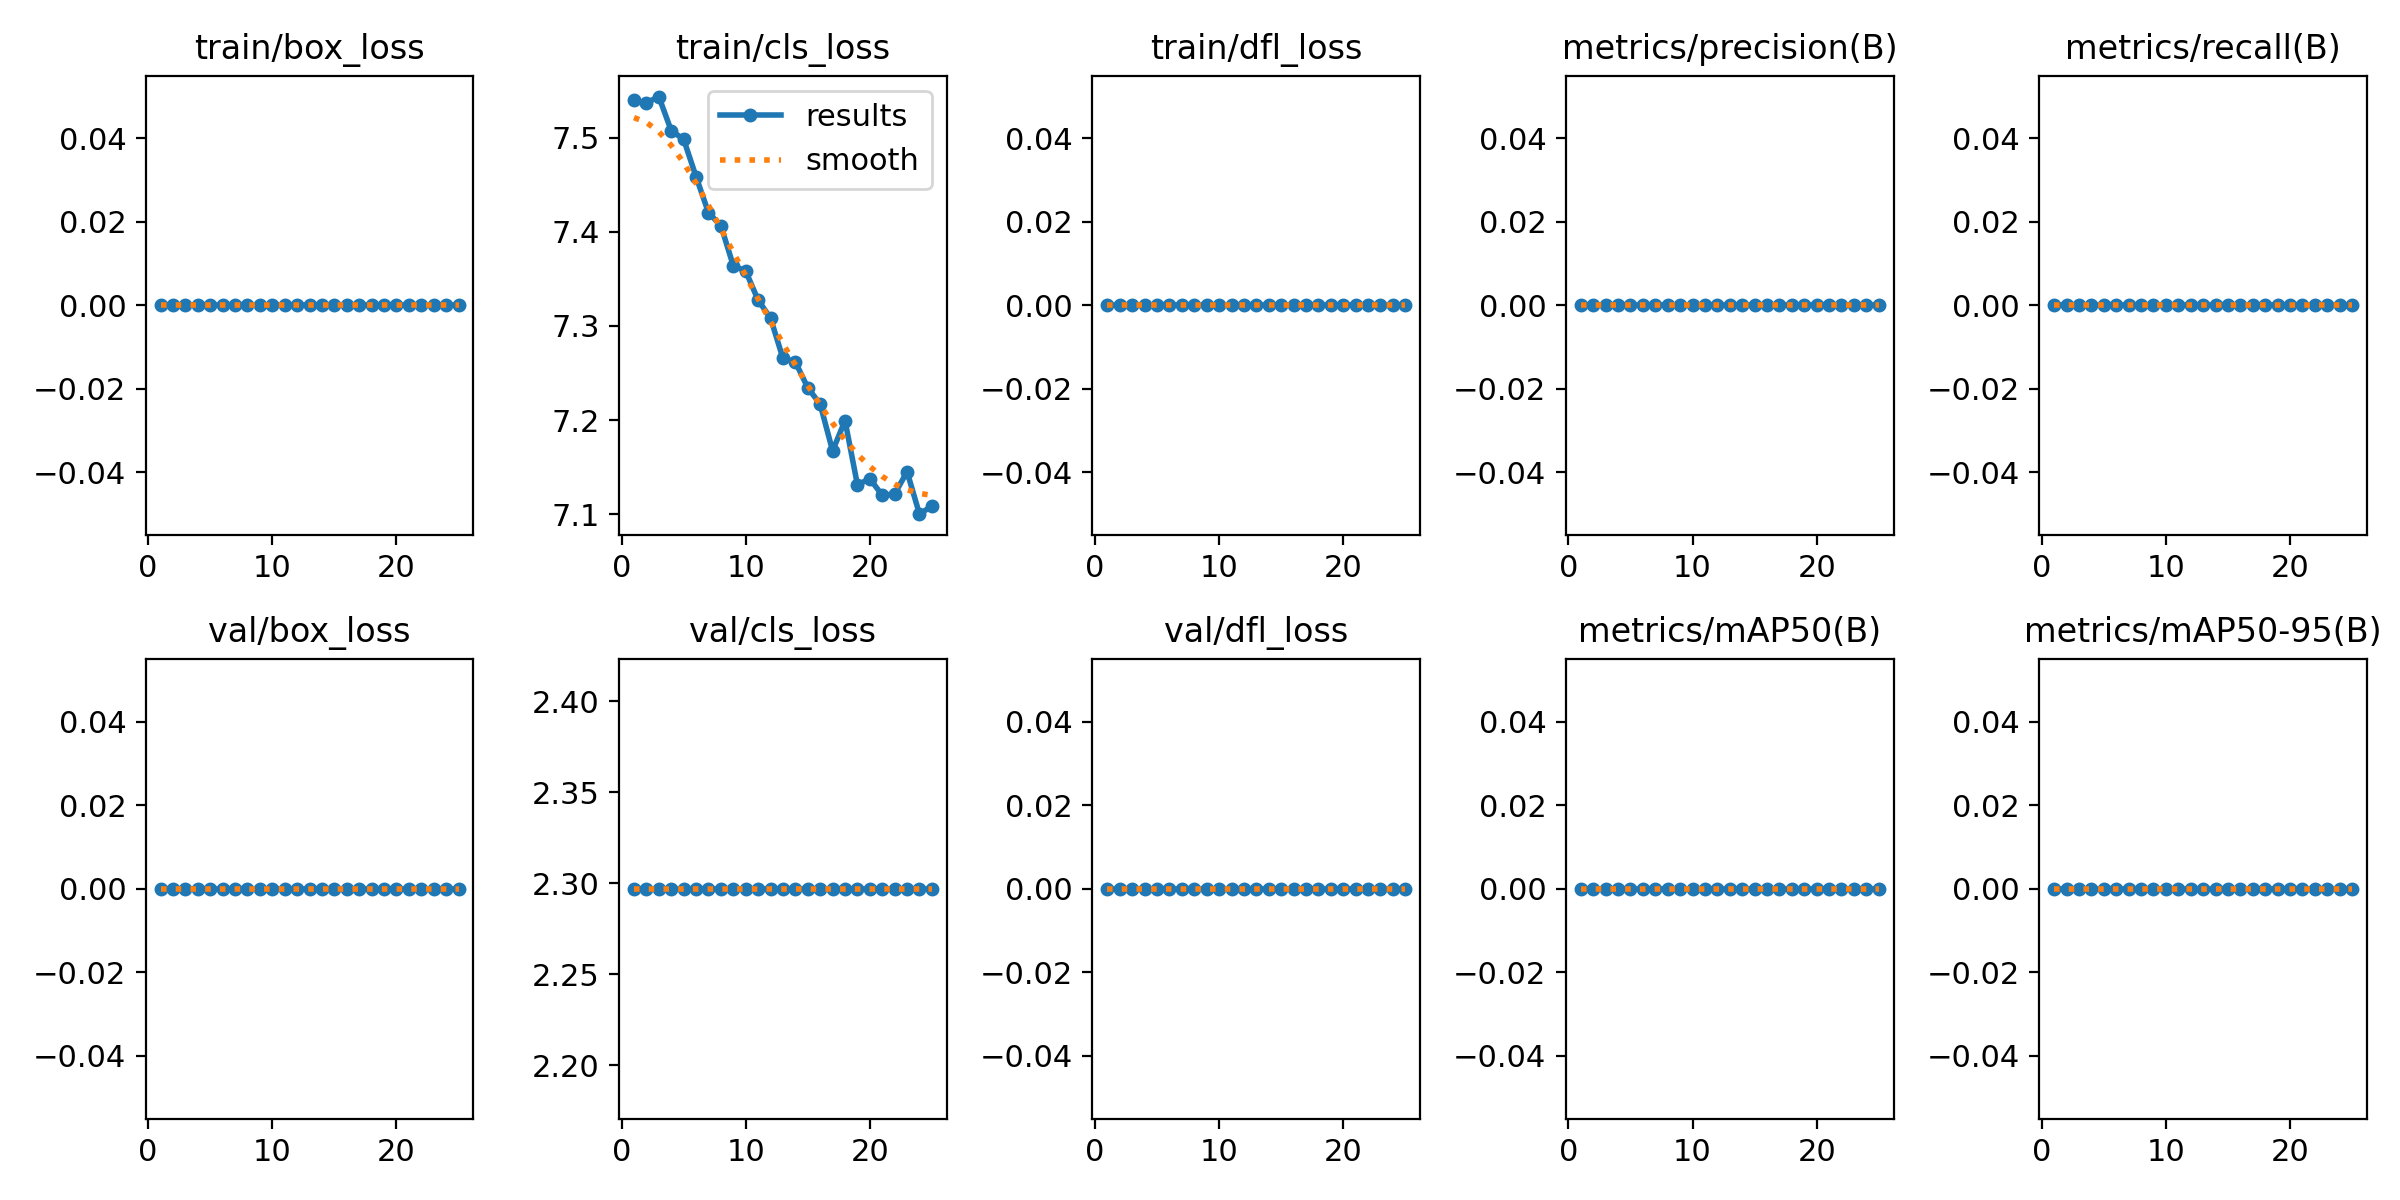


>>> confusion_matrix.png


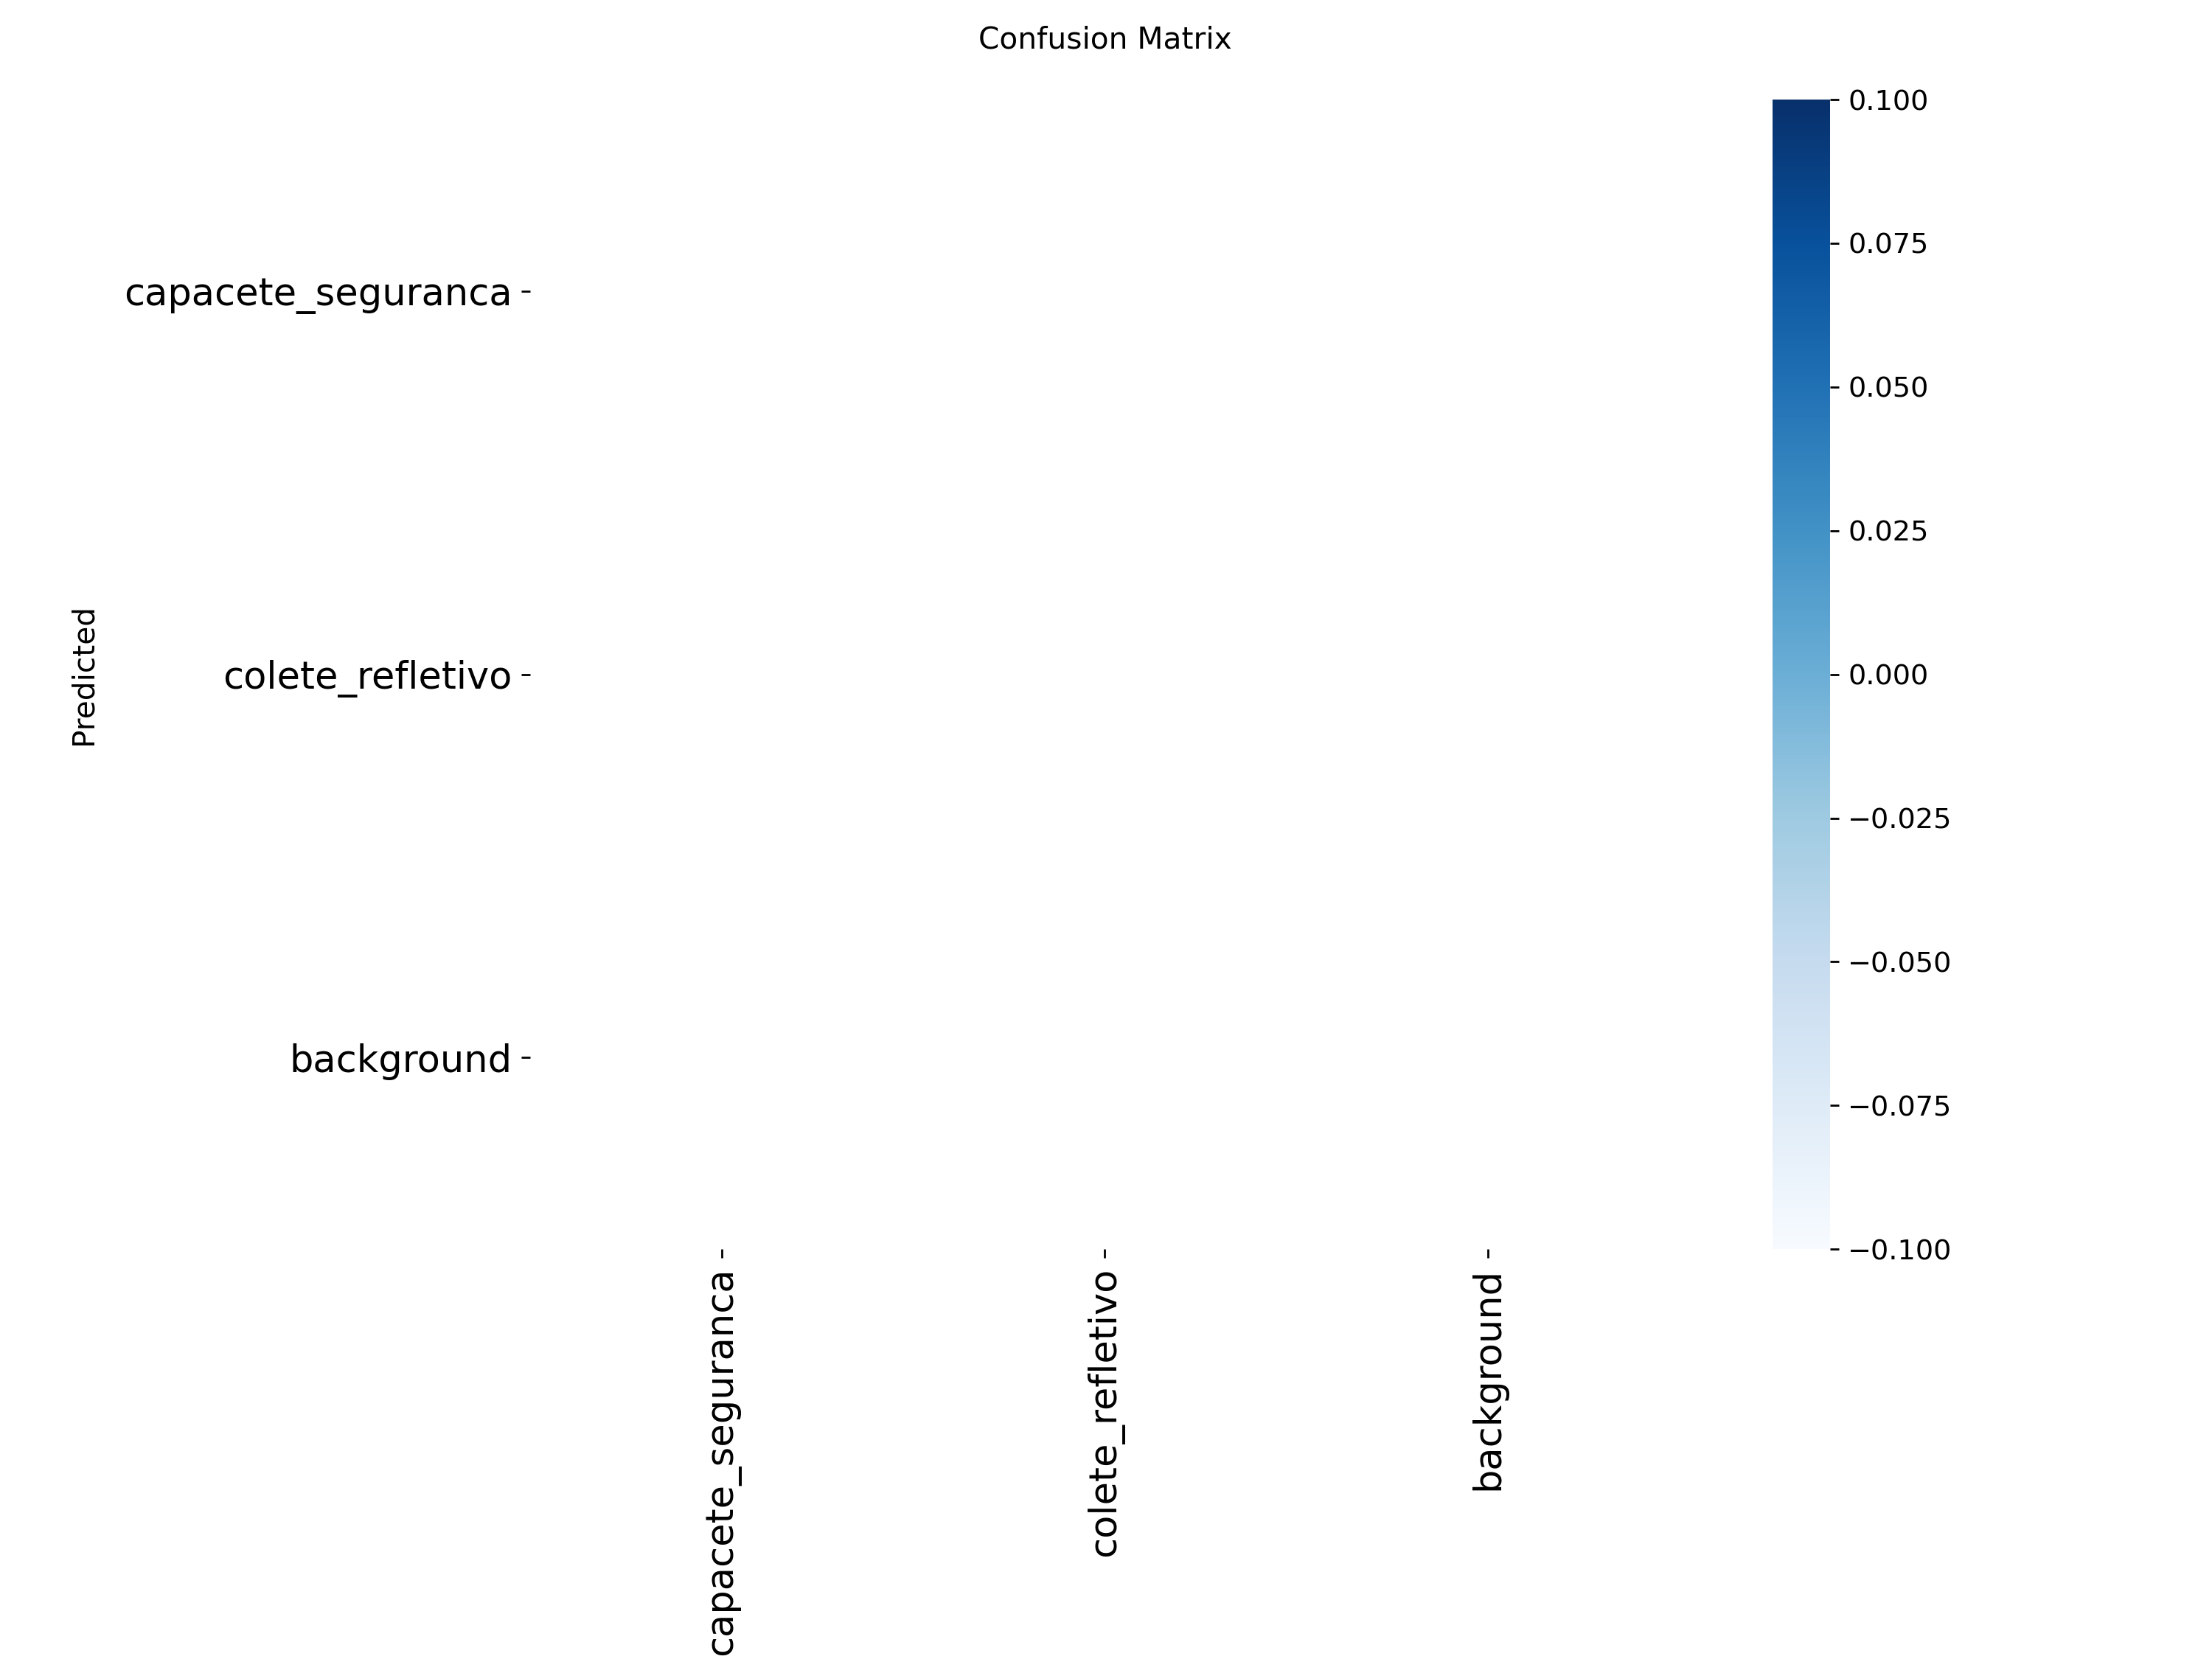


>>> val_batch0_pred.jpg


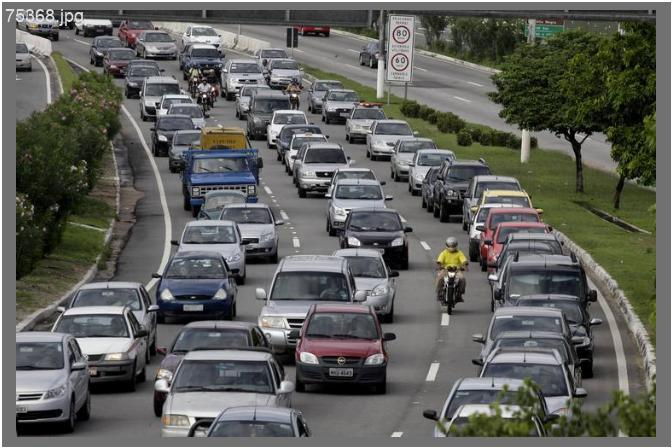

In [40]:
from IPython.display import Image, display
from pathlib import Path

run_dir = Path('/content/yolo_project/runs/train_custom')
for name in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    p = run_dir / name
    if p.exists():
        print(f'\n>>> {name}')
        display(Image(filename=str(p), width=800))

---
## 7. Detecção em imagem

Três modos:
- **7.1** Só modelo customizado (novas classes)
- **7.2** Só modelo COCO original (80 classes)
- **7.3** **Combinado** — classes novas + COCO (atende o requisito)

In [41]:
# ===== Escolher imagem de teste =====
from pathlib import Path

data_dir = Path('/content/yolo_project/dataset')
val_imgs = [p for p in data_dir.rglob('*.jpg')
            if 'val' in str(p).lower() or 'valid' in str(p).lower()]
if not val_imgs:
    val_imgs = list(data_dir.rglob('*.jpg'))[:5]

IMG_PATH = str(val_imgs[0])
print(f'Imagem escolhida: {IMG_PATH}')

Imagem escolhida: /content/yolo_project/dataset/images/val/75368.jpg


In [42]:
# ===== (Opcional) Upload da sua imagem =====
# Descomente o bloco para testar com uma foto sua
#
# from google.colab import files
# uploaded = files.upload()
# IMG_PATH = '/content/' + list(uploaded.keys())[0]
# print(f'Imagem enviada: {IMG_PATH}')

In [43]:
# ===== Funções auxiliares =====
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

def run_and_collect(weights_path, img_path, conf=0.25):
    """Roda o modelo e retorna lista de (x1,y1,x2,y2,conf,label)."""
    m = YOLO(weights_path)
    r = m.predict(source=img_path, conf=conf, verbose=False)[0]
    dets = []
    if r.boxes is not None:
        for b in r.boxes:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            dets.append((float(x1), float(y1), float(x2), float(y2),
                         float(b.conf[0]), r.names[int(b.cls[0])]))
    return dets

def color_for(label):
    palette = [(56,56,255),(49,210,207),(10,249,72),(255,194,0),
               (236,24,0),(255,56,132),(134,219,61),(23,204,146)]
    return palette[sum(ord(c) for c in label) % len(palette)]

def draw(image, dets):
    for x1, y1, x2, y2, conf, label in dets:
        p1, p2 = (int(x1), int(y1)), (int(x2), int(y2))
        color = color_for(label)
        cv2.rectangle(image, p1, p2, color, 2)
        text = f'{label} {conf:.2f}'
        (tw, th), bl = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(image, (p1[0], p1[1]-th-bl-4), (p1[0]+tw+4, p1[1]), color, -1)
        cv2.putText(image, text, (p1[0]+2, p1[1]-bl-2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
    return image

def show(img_bgr, title):
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

print('✅ Funções auxiliares carregadas')

✅ Funções auxiliares carregadas


### 7.1 Modelo CUSTOMIZADO (novas classes — transfer learning)

Modelo customizado detectou 0 objeto(s):


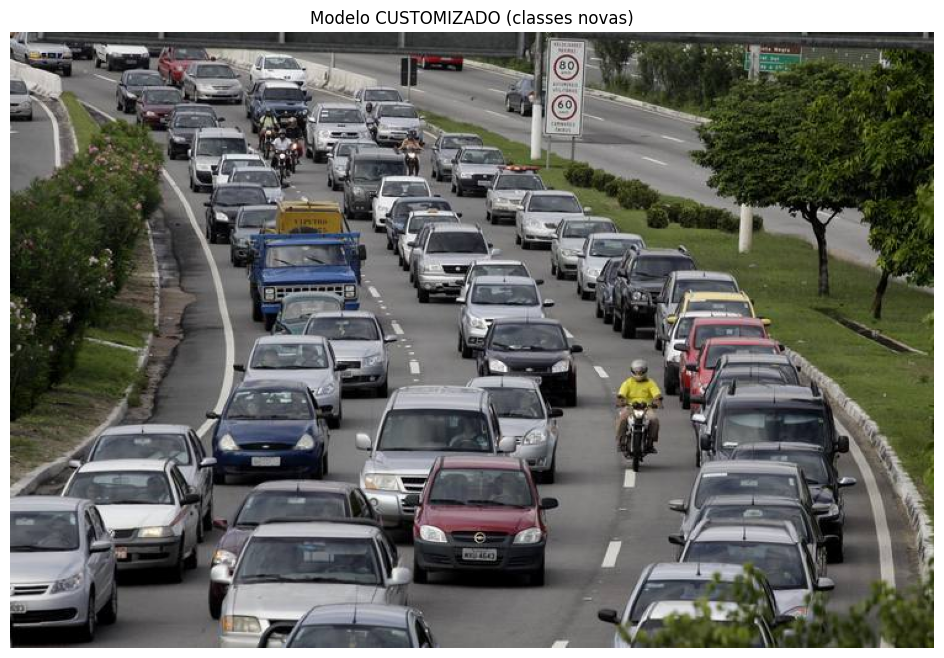

In [44]:
dets_custom = run_and_collect(str(BEST), IMG_PATH, conf=0.25)
print(f'Modelo customizado detectou {len(dets_custom)} objeto(s):')
for d in dets_custom:
    print(f'  {d[5]:20s} conf={d[4]:.3f}')

img = cv2.imread(IMG_PATH)
img_custom = draw(img.copy(), dets_custom)
show(img_custom, 'Modelo CUSTOMIZADO (classes novas)')

### 7.2 Modelo COCO ORIGINAL (80 classes pré-treinadas)

Modelo COCO detectou 55 objeto(s):
  car                  conf=0.891
  car                  conf=0.864
  car                  conf=0.857
  car                  conf=0.850
  car                  conf=0.798
  car                  conf=0.796
  car                  conf=0.776
  car                  conf=0.767
  car                  conf=0.763
  car                  conf=0.752
  car                  conf=0.723
  motorcycle           conf=0.718
  car                  conf=0.717
  car                  conf=0.716
  person               conf=0.705
  car                  conf=0.697
  car                  conf=0.692
  car                  conf=0.683
  car                  conf=0.639
  car                  conf=0.636
  car                  conf=0.620
  car                  conf=0.614
  car                  conf=0.562
  car                  conf=0.561
  car                  conf=0.545
  car                  conf=0.538
  truck                conf=0.535
  car                  conf=0.534
  car        

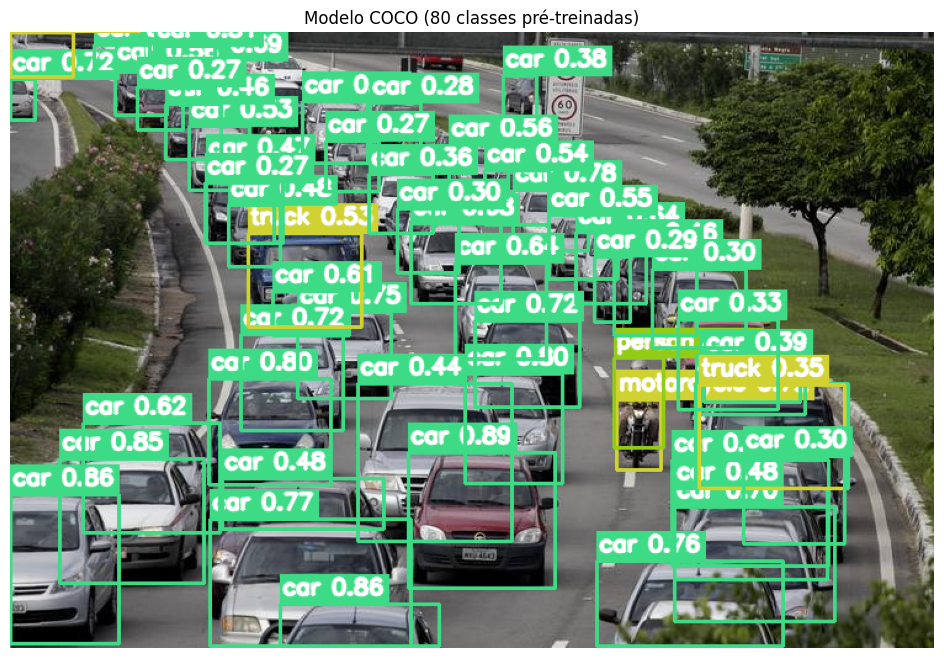

In [45]:
dets_coco = run_and_collect('yolov8n.pt', IMG_PATH, conf=0.25)
print(f'Modelo COCO detectou {len(dets_coco)} objeto(s):')
for d in dets_coco:
    print(f'  {d[5]:20s} conf={d[4]:.3f}')

img_coco = draw(img.copy(), dets_coco)
show(img_coco, 'Modelo COCO (80 classes pré-treinadas)')

### 7.3 COMBINADO — classes novas + classes COCO

Juntamos saídas dos dois modelos e aplicamos NMS entre eles para evitar caixas duplicadas.

Total combinado: 55 detecção(ões) (custom=0, adicionadas_do_coco=55)
  car                  conf=0.891
  car                  conf=0.864
  car                  conf=0.857
  car                  conf=0.850
  car                  conf=0.798
  car                  conf=0.796
  car                  conf=0.776
  car                  conf=0.767
  car                  conf=0.763
  car                  conf=0.752
  car                  conf=0.723
  motorcycle           conf=0.718
  car                  conf=0.717
  car                  conf=0.716
  person               conf=0.705
  car                  conf=0.697
  car                  conf=0.692
  car                  conf=0.683
  car                  conf=0.639
  car                  conf=0.636
  car                  conf=0.620
  car                  conf=0.614
  car                  conf=0.562
  car                  conf=0.561
  car                  conf=0.545
  car                  conf=0.538
  truck                conf=0.535
  car        

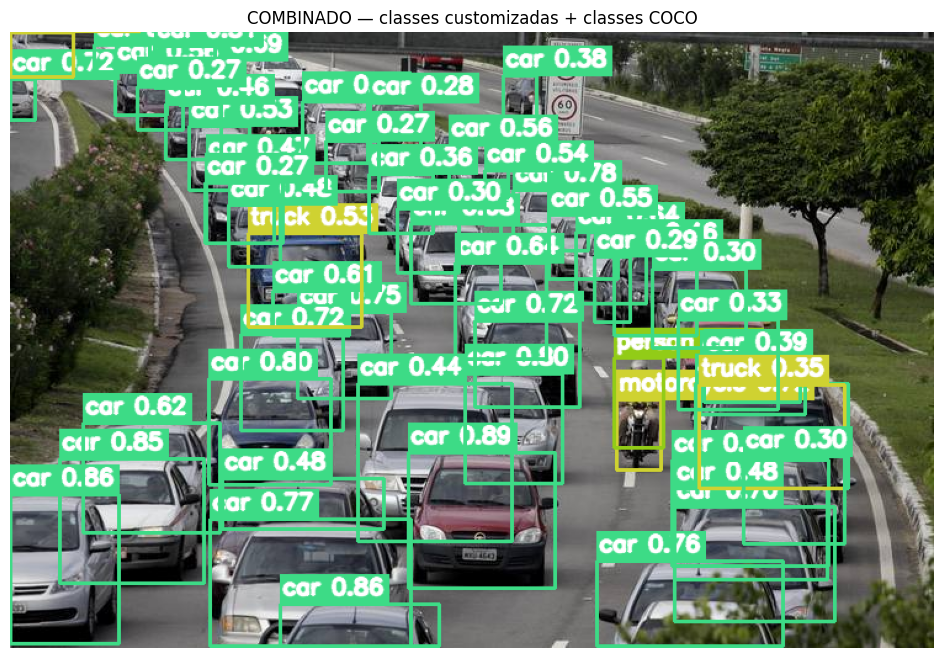

In [46]:
def iou(a, b):
    ax1,ay1,ax2,ay2 = a[:4]
    bx1,by1,bx2,by2 = b[:4]
    ix1,iy1 = max(ax1,bx1), max(ay1,by1)
    ix2,iy2 = min(ax2,bx2), min(ay2,by2)
    iw,ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw * ih
    ua = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter/ua if ua > 0 else 0.0

def merge(a, b, iou_thr=0.5):
    """Prioriza detecções do modelo custom; adiciona do COCO só se não sobrepuser."""
    out = list(a)
    for db in b:
        if all(iou(db, da) < iou_thr for da in a):
            out.append(db)
    return out

combined = merge(dets_custom, dets_coco, iou_thr=0.5)

print(f'Total combinado: {len(combined)} detecção(ões) '
      f'(custom={len(dets_custom)}, adicionadas_do_coco={len(combined)-len(dets_custom)})')
for d in combined:
    print(f'  {d[5]:20s} conf={d[4]:.3f}')

img_combined = draw(img.copy(), combined)
show(img_combined, 'COMBINADO — classes customizadas + classes COCO')

---
## 8. Salvar resultados e pesos

**Importante:** arquivos em `/content/` somem quando a sessão encerra. Salve o `best.pt` no Drive!

In [47]:
from pathlib import Path
import shutil

out_dir = Path('/content/yolo_project/outputs')
out_dir.mkdir(exist_ok=True)

cv2.imwrite(str(out_dir/'detect_custom.jpg'), img_custom)
cv2.imwrite(str(out_dir/'detect_coco.jpg'), img_coco)
cv2.imwrite(str(out_dir/'detect_combined.jpg'), img_combined)
shutil.copy(BEST, out_dir/'best.pt')

print('Salvo em /content/yolo_project/outputs:')
for p in out_dir.iterdir():
    print(f'  {p.name} ({p.stat().st_size/1024:.1f} KB)')

Salvo em /content/yolo_project/outputs:
  detect_coco.jpg (207.4 KB)
  detect_custom.jpg (150.3 KB)
  detect_combined.jpg (207.4 KB)
  best.pt (6080.7 KB)


In [48]:
# Copiar para o Drive (persistência)
try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')

    drive_out = Path('/content/drive/MyDrive/yolo_project_results')
    drive_out.mkdir(exist_ok=True)
    !cp -r /content/yolo_project/outputs/* "$drive_out"
    !cp -r /content/yolo_project/runs/train_custom "$drive_out"

    print(f'\n✅ Tudo salvo em: {drive_out}')
    print('Você pode fechar o Colab — os arquivos ficam no seu Drive.')
except Exception as e:
    print(f'⚠️  Erro ao salvar no Drive: {e}')

⚠️  Erro ao salvar no Drive: Error: credential propagation was unsuccessful


In [49]:
# Alternativa: baixar diretamente para seu PC
from google.colab import files
files.download(str(out_dir/'best.pt'))
files.download(str(out_dir/'detect_combined.jpg'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Pronto!

Você concluiu:
- ✅ Carregou um YOLOv8 pré-treinado no COCO
- ✅ Aplicou **transfer learning** para classes novas
- ✅ Detectou objetos com bounding boxes e classificação
- ✅ Combinou classes customizadas + classes COCO originais
- ✅ Salvou os pesos treinados no Drive

### 💡 Para reusar o modelo depois

Em um novo notebook:
```python
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/yolo_project_results/best.pt')
results = model.predict('sua_imagem.jpg')
```